# Digital Twin

This notebook demonstrates the `DigitalTwin` microscope for simulated image generation.

In [1]:
import sys
from pathlib import Path

# For resolving ModuleNotFoundErrors
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent.resolve()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import json

import numpy as np
import matplotlib.pyplot as plt
from asyncroscopy.ThermoDigitalTwin import ThermoDigitalTwin
from tango.test_context import MultiDeviceTestContext
from asyncroscopy.detectors.HAADF import HAADF
import tango

## Setup Tango Test Context

We spin up a local Tango server in the notebook process.

In [2]:
devices_info = [
    {
        "class": HAADF,
        "devices": [
            {
                "name": "test/nodb/haadf",
                "properties": {},
            }
        ],
    },
    {
        "class": ThermoDigitalTwin,
        "devices": [
            {
                "name": "test/nodb/twin",
                "properties": {
                    "haadf_device_address": "test/nodb/haadf",
                },
            }
        ],
    },
]

ctx = MultiDeviceTestContext(devices_info, process=False)
ctx.start()

proxy = tango.DeviceProxy("test/nodb/twin")
print(f"Device state: {proxy.state()}")
print(f"Manufacturer: {proxy.manufacturer}")

2026-03-06T19:50:47,159738-0500 INFO (HAADF.py:66) test/nodb/haadf HAADF device initialised
2026-03-06T19:50:47,160602-0500 INFO (ThermoDigitalTwin.py:57) test/nodb/twin Connected to detector proxy: haadf @ test/nodb/haadf
Ready to accept request
Device state: ON
Manufacturer: UTKTeam


## Acquire Simulated Image

Acquire an image from the HAADF detector and visualize it.

2026-03-06T19:50:47,181976-0500 INFO (ThermoDigitalTwin.py:72) test/nodb/twin Simulating haadf image: 1024x1024
Metadata: {'detector': 'haadf', 'shape': [1024, 1024], 'dtype': 'uint16', 'dwell_time': 1e-06, 'timestamp': 1772844647.2088509}


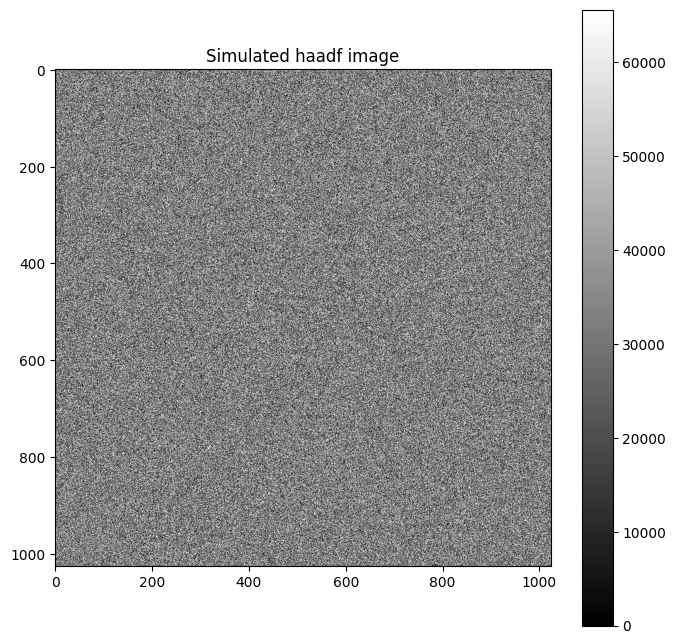

In [3]:
json_meta, raw_bytes = proxy.get_image("haadf")
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()

In [4]:
ctx.stop()